# EDA & Preprocessing for Goodreads Poetry (Explicit Feedback)

Notebook nay tap trung hoan toan vao tin hieu explicit feedback (`rating`) cho bai toan goi y sach.

## Quy trinh 6 buoc
1. Data Cleaning (chi giu rating trong [1, 5], loc nam >= 2007).
2. Visualization cho explicit insights (rating distribution, activity distribution).
3. Power-law check tren user/item interaction frequency.
4. Threshold sensitivity analysis voi K-core study va Kneedle elbow.
5. Iterative K-core filtering den khi hoi tu.
6. Final report va export artifacts.

In [ ]:
from pathlib import Path
from collections import Counter
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.options.display.float_format = '{:.4f}'.format

# ===== Config =====
INTERACTIONS_FILENAME = 'goodreads_interactions_poetry.json'
BOOKS_FILENAME = 'goodreads_books_poetry.json'
DATE_FORMAT = '%a %b %d %H:%M:%S %z %Y'
MIN_YEAR = 2007
VALID_RATINGS = {1, 2, 3, 4, 5}
DEDUP_INTERACTIONS = True
MAX_INTERACTION_LINES = None  # Set integer for quick debug

# Sensitivity + final filtering setup
K_VALUES = [1, 3, 5, 8, 10, 15, 20]

# Fair policy: final k must come from candidate set built by Elbow -> Sparsity -> Trade-off
K_SELECTION_POLICY = 'elbow_sparsity_tradeoff'

# Trade-off selection constraints (final decision stage)
MIN_USERS_RETAINED_PCT = 20.0
MIN_INTERACTIONS_RETAINED_PCT = 50.0
SPARSITY_CANDIDATE_QUANTILE = 0.50
TRADEOFF_WEIGHTS = {
    'users': 0.45,
    'interactions': 0.35,
    'sparsity_gain': 0.20,
}

# ===== Resolve data root robustly =====
cwd = Path.cwd()
search_roots = [cwd, cwd.parent, cwd.parent.parent]
ROOT_DATA_DIR = None
for root in search_roots:
    if (root / INTERACTIONS_FILENAME).exists():
        ROOT_DATA_DIR = root
        break
if ROOT_DATA_DIR is None:
    raise FileNotFoundError(f'Khong tim thay {INTERACTIONS_FILENAME} trong cac thu muc gan notebook.')

INTERACTIONS_PATH = ROOT_DATA_DIR / INTERACTIONS_FILENAME
BOOKS_PATH = ROOT_DATA_DIR / BOOKS_FILENAME

OUTPUT_DIR = ROOT_DATA_DIR / 'eda_outputs' / 'threshold_selection' / 'explicit_rating'
FIG_DIR = OUTPUT_DIR / 'figures'
CSV_DIR = OUTPUT_DIR / 'csv'
EXPORT_DIR = OUTPUT_DIR / 'exports'
for p in [OUTPUT_DIR, FIG_DIR, CSV_DIR, EXPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print({
    'root_data_dir': str(ROOT_DATA_DIR),
    'interactions_exists': INTERACTIONS_PATH.exists(),
    'books_exists': BOOKS_PATH.exists(),
    'output_dir': str(OUTPUT_DIR),
    'k_selection_policy': K_SELECTION_POLICY
})

{'root_data_dir': 'd:\\NAM3_UIT\\HK2\\MXH\\Data', 'interactions_exists': True, 'books_exists': True, 'output_dir': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating', 'k_selection_policy': 'tradeoff_density'}


## Step 1 - Data Cleaning (Explicit Focus)

Quy tac clean:
- Chi giu interaction co `rating` thuoc [1, 5].
- Loai bo rating = 0, missing hoac khong parse duoc.
- Parse `date_added` sang datetime va chi giu interaction tu nam 2007 tro di.
- Deduplicate theo (`user_id`, `book_id`) va uu tien ban ghi co `date_added` moi hon.

In [3]:
def parse_interaction_datetime(date_raw: str):
    if not date_raw:
        return pd.NaT
    return pd.to_datetime(date_raw, format=DATE_FORMAT, errors='coerce')


def as_decimal(x, ndigits: int = 4):
    return float(f'{float(x):.{ndigits}f}')


def pretty_number(x, ndigits: int = 8):
    # Integer-like values are shown without decimal part; decimal values keep significant fractional digits.
    if pd.isna(x):
        return ''
    x_float = float(x)
    if abs(x_float - round(x_float)) < 10 ** (-ndigits):
        return str(int(round(x_float)))
    return f'{x_float:.{ndigits}f}'.rstrip('0').rstrip('.')


raw_rows = 0
json_parse_errors = 0
missing_user_or_item = 0
invalid_rating_rows = 0
missing_date_added_rows = 0
date_parse_error_rows = 0
below_min_year_rows = 0
duplicate_older_rows = 0

records_by_key = {}

with INTERACTIONS_PATH.open('r', encoding='utf-8') as f:
    for line_no, line in enumerate(f, start=1):
        if MAX_INTERACTION_LINES is not None and line_no > MAX_INTERACTION_LINES:
            break

        line = line.strip()
        if not line:
            continue

        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            json_parse_errors += 1
            continue

        raw_rows += 1

        user_id = str(rec.get('user_id', '')).strip()
        book_id = str(rec.get('book_id', '')).strip()
        if not user_id or not book_id:
            missing_user_or_item += 1
            continue

        try:
            rating = int(rec.get('rating', 0))
        except (TypeError, ValueError):
            rating = 0

        if rating not in VALID_RATINGS:
            invalid_rating_rows += 1
            continue

        date_added_raw = str(rec.get('date_added', '')).strip()
        if not date_added_raw:
            missing_date_added_rows += 1
            continue

        dt = parse_interaction_datetime(date_added_raw)
        if pd.isna(dt):
            date_parse_error_rows += 1
            continue

        if int(dt.year) < MIN_YEAR:
            below_min_year_rows += 1
            continue

        dedup_key = (user_id, book_id)
        row = {
            'user_id': user_id,
            'book_id': book_id,
            'rating': int(rating),
            'date_added': dt,
        }

        if DEDUP_INTERACTIONS:
            old = records_by_key.get(dedup_key)
            if old is None:
                records_by_key[dedup_key] = row
            else:
                if row['date_added'] > old['date_added']:
                    records_by_key[dedup_key] = row
                    duplicate_older_rows += 1
                else:
                    duplicate_older_rows += 1
        else:
            records_by_key[(dedup_key, len(records_by_key))] = row

explicit_df = pd.DataFrame(records_by_key.values())
if len(explicit_df) == 0:
    raise RuntimeError('Sau khi clean khong con du lieu. Kiem tra lai dieu kien loc.')

explicit_df = explicit_df.sort_values('date_added').reset_index(drop=True)

raw_explicit_users = explicit_df['user_id'].nunique()
raw_explicit_items = explicit_df['book_id'].nunique()
raw_explicit_interactions = len(explicit_df)
raw_explicit_density = raw_explicit_interactions / (raw_explicit_users * raw_explicit_items)
raw_explicit_sparsity = 1.0 - raw_explicit_density

# Print theo format dictionary tuong tu output mau, voi so thap phan
explicit_cleaning_stats = {
    'interaction_rows_raw': as_decimal(raw_rows),
    'interaction_rows_after_dedup': as_decimal(raw_explicit_interactions),
    'duplicate_rows_skipped': as_decimal(duplicate_older_rows),
    'explicit_interaction_rows': as_decimal(raw_explicit_interactions),
    'date_added_interaction_rows': as_decimal(raw_explicit_interactions),
    'date_added_interaction_ratio': as_decimal(1.0),
    'missing_date_added_rows': as_decimal(missing_date_added_rows),
    'year_filter_enabled': True,
    'min_interaction_year': as_decimal(MIN_YEAR),
    'year_filtered_out_rows': as_decimal(below_min_year_rows),
    'year_parse_errors_main': as_decimal(date_parse_error_rows),
    'explicit_interaction_ratio': as_decimal(raw_explicit_interactions / raw_rows) if raw_rows else as_decimal(0.0),
    'unique_users_explicit': as_decimal(raw_explicit_users),
    'unique_books_explicit': as_decimal(raw_explicit_items),
    'parse_errors': as_decimal(json_parse_errors),
    'threshold_mode': 'explicit',
    'activity_mode_for_threshold': 'explicit interactions with rating in [1,5] and year >= 2007'
}
print(explicit_cleaning_stats)

cleaning_summary = pd.DataFrame([
    {'metric': 'raw_rows_seen', 'value': as_decimal(raw_rows)},
    {'metric': 'json_parse_errors', 'value': as_decimal(json_parse_errors)},
    {'metric': 'missing_user_or_item', 'value': as_decimal(missing_user_or_item)},
    {'metric': 'invalid_rating_rows', 'value': as_decimal(invalid_rating_rows)},
    {'metric': 'missing_date_added_rows', 'value': as_decimal(missing_date_added_rows)},
    {'metric': 'date_parse_error_rows', 'value': as_decimal(date_parse_error_rows)},
    {'metric': 'below_min_year_rows', 'value': as_decimal(below_min_year_rows)},
    {'metric': 'duplicate_older_rows', 'value': as_decimal(duplicate_older_rows)},
    {'metric': 'explicit_rows_after_clean', 'value': as_decimal(raw_explicit_interactions)},
    {'metric': 'users_after_clean', 'value': as_decimal(raw_explicit_users)},
    {'metric': 'items_after_clean', 'value': as_decimal(raw_explicit_items)},
    {'metric': 'density_after_clean', 'value': as_decimal(raw_explicit_density, 8)},
    {'metric': 'sparsity_after_clean', 'value': as_decimal(raw_explicit_sparsity, 8)},
])

cleaning_summary_display = cleaning_summary.copy()
cleaning_summary_display['value'] = cleaning_summary_display['value'].apply(pretty_number)

display(cleaning_summary_display)
explicit_df.head()

{'interaction_rows_raw': 2734350.0, 'interaction_rows_after_dedup': 1228992.0, 'duplicate_rows_skipped': 0.0, 'explicit_interaction_rows': 1228992.0, 'date_added_interaction_rows': 1228992.0, 'date_added_interaction_ratio': 1.0, 'missing_date_added_rows': 0.0, 'year_filter_enabled': True, 'min_interaction_year': 2007.0, 'year_filtered_out_rows': 67.0, 'year_parse_errors_main': 0.0, 'explicit_interaction_ratio': 0.4495, 'unique_users_explicit': 267818.0, 'unique_books_explicit': 36181.0, 'parse_errors': 0.0, 'threshold_mode': 'explicit', 'activity_mode_for_threshold': 'explicit interactions with rating in [1,5] and year >= 2007'}


,metric,value
0,raw_rows_seen,2734350
1,json_parse_errors,0
2,missing_user_or_item,0
3,invalid_rating_rows,1505291
4,missing_date_added_rows,0
5,date_parse_error_rows,0
6,below_min_year_rows,67
7,duplicate_older_rows,0
8,explicit_rows_after_clean,1228992
9,users_after_clean,267818


,user_id,book_id,rating,date_added
0,3d3ffd91a1e83bd933a7a8304f186aff,438285,3,2007-01-12 00:00:00-08:00
1,238c8dd27105c8b9625a82e97bb72ca3,15997,4,2007-01-12 00:51:37-08:00
2,238c8dd27105c8b9625a82e97bb72ca3,1381,5,2007-01-12 00:52:22-08:00
3,238c8dd27105c8b9625a82e97bb72ca3,30118,4,2007-01-12 00:54:54-08:00
4,8842281e1d1347389f2ab93d60773d4d,30119,5,2007-01-13 13:44:20-08:00


## Step 2 - Visualization (Explicit Insights)

Bao gom:
- Rating distribution (bar chart cho 1..5).
- Activity distribution tren User va Item (histogram, log-scale truc Y).
- Power-law check bang do thi log-log frequency.

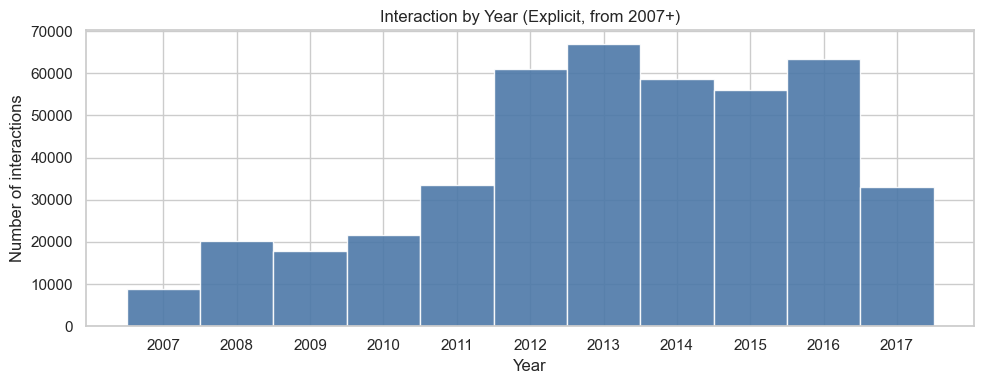

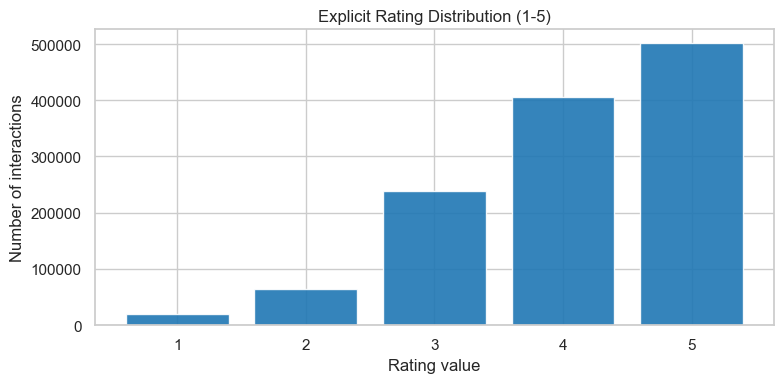

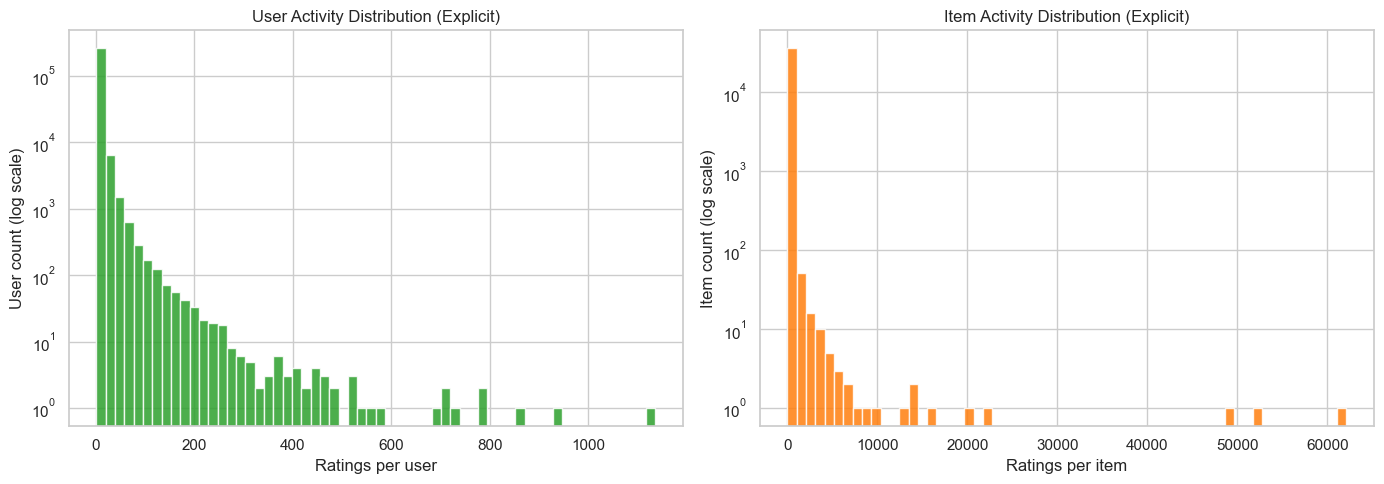

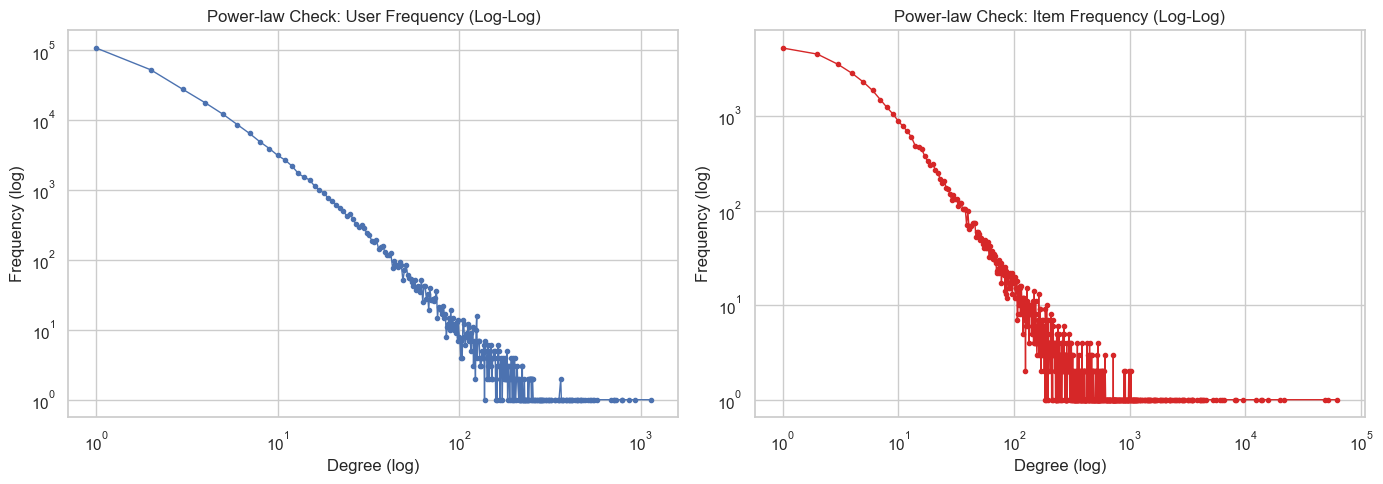

{'interaction_by_year_fig': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\figures\\interaction_by_year_explicit.png', 'rating_distribution_fig': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\figures\\rating_distribution_explicit.png', 'activity_distribution_fig': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\figures\\activity_distribution_explicit_logy.png', 'powerlaw_fig': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\figures\\powerlaw_check_user_item_loglog.png'}


In [5]:
# Prepare degree statistics
user_degree_raw = explicit_df.groupby('user_id').size()
item_degree_raw = explicit_df.groupby('book_id').size()

# 2.0 Interaction by year (histogram) - placed first as requested
date_added_series = pd.to_datetime(explicit_df['date_added'], errors='coerce')
year_values = date_added_series.dt.year.dropna().astype(int)
if len(year_values) == 0:
    raise RuntimeError('Khong co date_added hop le de ve histogram interaction by year.')

year_min = int(year_values.min())
year_max = int(year_values.max())
year_bins = np.arange(year_min, year_max + 2) - 0.5

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(year_values, bins=year_bins, color='#4c78a8', alpha=0.9, edgecolor='white')
ax.set_title(f'Interaction by Year (Explicit, from {MIN_YEAR}+)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of interactions')
ax.set_xticks(np.arange(year_min, year_max + 1, max(1, (year_max - year_min) // 12 + 1)))
plt.tight_layout()
interaction_by_year_fig = FIG_DIR / 'interaction_by_year_explicit.png'
fig.savefig(interaction_by_year_fig, dpi=160, bbox_inches='tight')
plt.show()

# 2.1 Rating Distribution
rating_dist = explicit_df['rating'].value_counts().reindex([1, 2, 3, 4, 5], fill_value=0).sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rating_dist.index.astype(str), rating_dist.values, color='#1f77b4', alpha=0.9)
ax.set_title('Explicit Rating Distribution (1-5)')
ax.set_xlabel('Rating value')
ax.set_ylabel('Number of interactions')
plt.tight_layout()
rating_dist_fig = FIG_DIR / 'rating_distribution_explicit.png'
fig.savefig(rating_dist_fig, dpi=160, bbox_inches='tight')
plt.show()

# 2.2 Activity Distribution (User & Item)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(user_degree_raw.values, bins=60, color='#2ca02c', alpha=0.85, log=True)
axes[0].set_title('User Activity Distribution (Explicit)')
axes[0].set_xlabel('Ratings per user')
axes[0].set_ylabel('User count (log scale)')

axes[1].hist(item_degree_raw.values, bins=60, color='#ff7f0e', alpha=0.85, log=True)
axes[1].set_title('Item Activity Distribution (Explicit)')
axes[1].set_xlabel('Ratings per item')
axes[1].set_ylabel('Item count (log scale)')
plt.tight_layout()
activity_hist_fig = FIG_DIR / 'activity_distribution_explicit_logy.png'
fig.savefig(activity_hist_fig, dpi=160, bbox_inches='tight')
plt.show()

# 2.3 Power-law Check (Log-Log frequency)
def frequency_of_degree(series_counts: pd.Series) -> pd.DataFrame:
    c = Counter(series_counts.values.tolist())
    out = pd.DataFrame({'degree': list(c.keys()), 'frequency': list(c.values())})
    out = out.sort_values('degree').reset_index(drop=True)
    return out

user_freq_df = frequency_of_degree(user_degree_raw)
item_freq_df = frequency_of_degree(item_degree_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(user_freq_df['degree'], user_freq_df['frequency'], marker='o', linewidth=1, markersize=3)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Power-law Check: User Frequency (Log-Log)')
axes[0].set_xlabel('Degree (log)')
axes[0].set_ylabel('Frequency (log)')

axes[1].plot(item_freq_df['degree'], item_freq_df['frequency'], marker='o', linewidth=1, markersize=3, color='#d62728')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Power-law Check: Item Frequency (Log-Log)')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
powerlaw_fig = FIG_DIR / 'powerlaw_check_user_item_loglog.png'
fig.savefig(powerlaw_fig, dpi=160, bbox_inches='tight')
plt.show()

print({
    'interaction_by_year_fig': str(interaction_by_year_fig),
    'rating_distribution_fig': str(rating_dist_fig),
    'activity_distribution_fig': str(activity_hist_fig),
    'powerlaw_fig': str(powerlaw_fig)
})

## Step 3 - Threshold Sensitivity Analysis (Elbow -> Sparsity -> Trade-off)

Voi moi nguong $k \in \{1, 3, 5, 8, 10, 15, 20\}$:
- Chay iterative k-core den hoi tu.
- Ghi nhan Users, Items, Interactions con lai.
- Tinh retention, density va sparsity.

Quy trinh chon $k$ cong bang:
- Stage A (Elbow): tim moc tham chieu bang Kneedle.
- Stage B (Sparsity): loc tap ung vien theo sparsity tot hon.
- Stage C (Trade-off): ra quyet dinh cuoi cung tu tap ung vien (users + interactions + sparsity_gain).

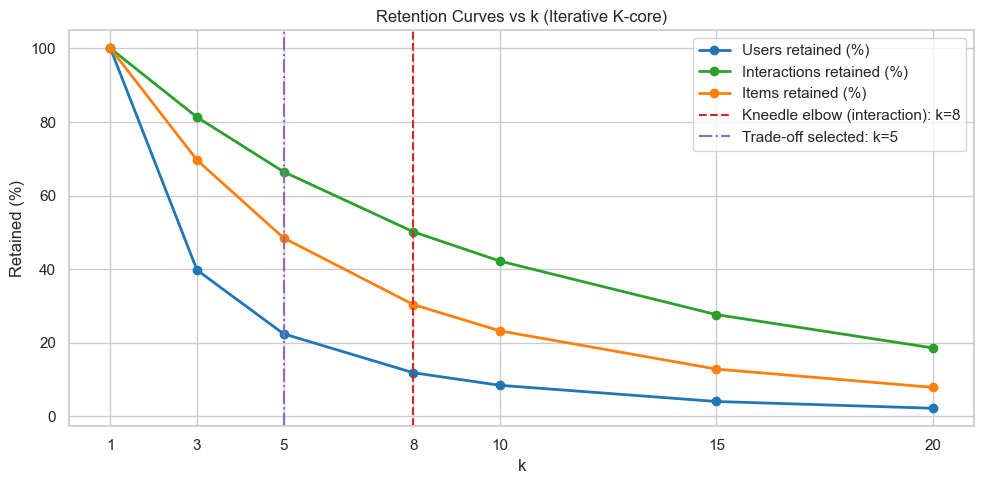

,k,users,items,interactions,users_retained_pct,items_retained_pct,interactions_retained_pct,retention_pct,density,sparsity,kcore_iterations,min_user_degree_after,min_item_degree_after,kneedle_distance
0,1,267818,36181,1228992,100.0000,100.0000,100.0000,100.0000,0.0001,0.9999,1,1,1,0.0000
1,3,106497,25197,999241,39.7647,69.6415,81.3057,81.3057,0.0004,0.9996,6,3,3,0.1244
2,5,60102,17549,816905,22.4414,48.5034,66.4695,66.4695,0.0008,0.9992,10,5,5,0.2015
3,8,31774,10993,616409,11.8640,30.3834,50.1557,50.1557,0.0018,0.9982,8,8,8,0.2440
4,10,22647,8410,518582,8.4561,23.2442,42.1957,42.1957,0.0027,0.9973,12,10,10,0.2365
5,15,10867,4654,339938,4.0576,12.8631,27.6599,27.6599,0.0067,0.9933,14,15,15,0.1520
6,20,5947,2856,228733,2.2205,7.8936,18.6114,18.6114,0.0135,0.9865,12,20,20,0.0000


,k,users_retained_pct,interactions_retained_pct,density,users_score,interactions_score,density_score,tradeoff_score
2,5,22.4414,66.4695,0.0008,1.0000,1.0000,1.0000,1.0000


,method,recommended_k,why
0,kneedle_reference,8,Diem gay tren duong interactions retained (%)
1,tradeoff_density_constraints,5,"Can bang users/interactions/density, voi users..."


{'elbow_k': 8, 'tradeoff_k': 5, 'density_cutoff': 0.0005734468858772692, 'retention_curve_fig': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\figures\\retention_curves_tradeoff_density_kneedle_explicit.png'}


In [ ]:
def compute_density_sparsity(n_users: int, n_items: int, n_edges: int):
    denom = n_users * n_items
    density = (n_edges / denom) if denom else 0.0
    sparsity = 1.0 - density if denom else 1.0
    return density, sparsity


def iterative_kcore_from_edges(edge_df: pd.DataFrame, k: int, max_iter: int = 100):
    work_df = edge_df[['user_id', 'book_id', 'rating', 'date_added']].copy()
    logs = []

    for it in range(1, max_iter + 1):
        n_prev = len(work_df)
        user_deg = work_df.groupby('user_id').size()
        item_deg = work_df.groupby('book_id').size()

        valid_users = set(user_deg[user_deg >= k].index)
        valid_items = set(item_deg[item_deg >= k].index)

        new_df = work_df[
            work_df['user_id'].isin(valid_users) &
            work_df['book_id'].isin(valid_items)
        ].copy()

        logs.append({
            'iteration': it,
            'edges_before': int(n_prev),
            'users_before': int(user_deg.shape[0]),
            'items_before': int(item_deg.shape[0]),
            'edges_after': int(len(new_df)),
            'users_after': int(new_df['user_id'].nunique()),
            'items_after': int(new_df['book_id'].nunique()),
            'removed_edges_this_iter': int(n_prev - len(new_df))
        })

        work_df = new_df
        if n_prev == len(work_df):
            break

    # Final degree check after convergence
    if len(work_df) > 0:
        u_min = int(work_df.groupby('user_id').size().min())
        i_min = int(work_df.groupby('book_id').size().min())
    else:
        u_min, i_min = 0, 0

    return work_df.reset_index(drop=True), pd.DataFrame(logs), u_min, i_min


def kneedle_elbow(k_values, y_values):
    x = np.array(k_values, dtype=float)
    y = np.array(y_values, dtype=float)

    if len(x) < 2:
        return int(k_values[0]), np.zeros_like(x)

    x_span = x.max() - x.min()
    x_norm = (x - x.min()) / x_span if x_span > 0 else np.zeros_like(x)

    y_span = y.max() - y.min()
    y_norm = (y - y.min()) / y_span if y_span > 0 else np.zeros_like(y)

    line = 1.0 - x_norm
    dist = line - y_norm
    idx = int(np.argmax(dist))
    return int(k_values[idx]), dist


def minmax_norm(series: pd.Series) -> pd.Series:
    series = series.astype(float)
    span = float(series.max() - series.min())
    if span == 0:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - series.min()) / span


baseline_users = int(explicit_df['user_id'].nunique())
baseline_items = int(explicit_df['book_id'].nunique())
baseline_edges = int(len(explicit_df))

sensitivity_rows = []
kcore_outputs_by_k = {}

for k in K_VALUES:
    filtered_k_df, iter_log_k, min_user_deg_k, min_item_deg_k = iterative_kcore_from_edges(explicit_df, k=k)

    n_users = int(filtered_k_df['user_id'].nunique()) if len(filtered_k_df) else 0
    n_items = int(filtered_k_df['book_id'].nunique()) if len(filtered_k_df) else 0
    n_edges = int(len(filtered_k_df))
    density_k, sparsity_k = compute_density_sparsity(n_users, n_items, n_edges)

    users_retained_pct = (100.0 * n_users / baseline_users) if baseline_users else 0.0
    items_retained_pct = (100.0 * n_items / baseline_items) if baseline_items else 0.0
    interactions_retained_pct = (100.0 * n_edges / baseline_edges) if baseline_edges else 0.0

    sensitivity_rows.append({
        'k': int(k),
        'users': n_users,
        'items': n_items,
        'interactions': n_edges,
        'users_retained_pct': users_retained_pct,
        'items_retained_pct': items_retained_pct,
        'interactions_retained_pct': interactions_retained_pct,
        # Keep legacy name for downstream compatibility.
        'retention_pct': interactions_retained_pct,
        'density': density_k,
        'sparsity': sparsity_k,
        'kcore_iterations': int(len(iter_log_k)),
        'min_user_degree_after': int(min_user_deg_k),
        'min_item_degree_after': int(min_item_deg_k)
    })

    kcore_outputs_by_k[int(k)] = {
        'filtered_df': filtered_k_df,
        'iter_log': iter_log_k,
        'min_user_deg': min_user_deg_k,
        'min_item_deg': min_item_deg_k
    }

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values('k').reset_index(drop=True)

# Stage A - Elbow reference from interaction-retained curve
elbow_k, kneedle_distance = kneedle_elbow(
    sensitivity_df['k'].tolist(),
    sensitivity_df['interactions_retained_pct'].tolist()
)
sensitivity_df['kneedle_distance'] = kneedle_distance

# Candidate pool starts from elbow stage and must remain on defined K_VALUES
candidate_pool = sensitivity_df[sensitivity_df['k'] <= elbow_k].copy()
if len(candidate_pool) == 0:
    candidate_pool = sensitivity_df.copy()

# Stage B - Sparsity gate: keep denser part of candidate pool
sparsity_cutoff = float(candidate_pool['sparsity'].quantile(SPARSITY_CANDIDATE_QUANTILE))
sparsity_candidates = candidate_pool[candidate_pool['sparsity'] <= sparsity_cutoff].copy()
if len(sparsity_candidates) == 0:
    keep_n = max(1, len(candidate_pool) // 2)
    sparsity_candidates = candidate_pool.nsmallest(keep_n, 'sparsity').copy()

# Stage C - Trade-off final decision from filtered candidate set
tradeoff_candidates = sparsity_candidates[
    (sparsity_candidates['users_retained_pct'] >= MIN_USERS_RETAINED_PCT) &
    (sparsity_candidates['interactions_retained_pct'] >= MIN_INTERACTIONS_RETAINED_PCT)
] .copy()

if len(tradeoff_candidates) == 0:
    tradeoff_candidates = sparsity_candidates.copy()

tradeoff_candidates['users_score'] = minmax_norm(tradeoff_candidates['users_retained_pct'])
tradeoff_candidates['interactions_score'] = minmax_norm(tradeoff_candidates['interactions_retained_pct'])
tradeoff_candidates['sparsity_gain_score'] = minmax_norm(-tradeoff_candidates['sparsity'])
tradeoff_candidates['tradeoff_score'] = (
    TRADEOFF_WEIGHTS['users'] * tradeoff_candidates['users_score'] +
    TRADEOFF_WEIGHTS['interactions'] * tradeoff_candidates['interactions_score'] +
    TRADEOFF_WEIGHTS['sparsity_gain'] * tradeoff_candidates['sparsity_gain_score']
)

tradeoff_row = tradeoff_candidates.sort_values(
    ['tradeoff_score', 'sparsity', 'k'],
    ascending=[False, True, True]
).iloc[0]
tradeoff_k = int(tradeoff_row['k'])
candidate_k_set = sorted(int(x) for x in tradeoff_candidates['k'].tolist())

threshold_methods = pd.DataFrame([
    {
        'method': 'stage_a_elbow_reference',
        'recommended_k': int(elbow_k),
        'why': 'Kneedle tren duong interactions retained (%)'
    },
    {
        'method': 'stage_b_sparsity_gate',
        'recommended_k': ','.join(str(x) for x in sorted(int(v) for v in sparsity_candidates['k'].tolist())),
        'why': f'Giu cac k co sparsity <= Q{int(SPARSITY_CANDIDATE_QUANTILE * 100)} cua candidate pool'
    },
    {
        'method': 'stage_c_tradeoff_final',
        'recommended_k': int(tradeoff_k),
        'why': (
            f'Quyet dinh cuoi cung tu tap ung vien voi users>={MIN_USERS_RETAINED_PCT:.1f}%, '
            f'interactions>={MIN_INTERACTIONS_RETAINED_PCT:.1f}% va sparsity_gain'
        )
    }
])

fig, ax = plt.subplots(figsize=(10, 5))

# Fixed colors for easier comparison: user=blue, interaction=green, item=orange.
ax.plot(
    sensitivity_df['k'],
    sensitivity_df['users_retained_pct'],
    marker='o',
    linewidth=2,
    color='#1f77b4',
    label='Users retained (%)'
)
ax.plot(
    sensitivity_df['k'],
    sensitivity_df['interactions_retained_pct'],
    marker='o',
    linewidth=2,
    color='#2ca02c',
    label='Interactions retained (%)'
)
ax.plot(
    sensitivity_df['k'],
    sensitivity_df['items_retained_pct'],
    marker='o',
    linewidth=2,
    color='#ff7f0e',
    label='Items retained (%)'
)

ax.axvline(elbow_k, color='#d62728', linestyle='--', label=f'Elbow reference: k={elbow_k}')
ax.axvline(tradeoff_k, color='#9467bd', linestyle='-.', label=f'Trade-off final: k={tradeoff_k}')
ax.set_title('Retention Curves vs k (Iterative K-core)')
ax.set_xlabel('k')
ax.set_ylabel('Retained (%)')
ax.set_xticks(sensitivity_df['k'])
ax.legend()
plt.tight_layout()
retention_curve_fig = FIG_DIR / 'retention_curves_elbow_sparsity_tradeoff_explicit.png'
fig.savefig(retention_curve_fig, dpi=160, bbox_inches='tight')
plt.show()

display(sensitivity_df)
display(sparsity_candidates[['k', 'users_retained_pct', 'interactions_retained_pct', 'sparsity', 'density']].sort_values('k'))
display(tradeoff_candidates[['k', 'users_retained_pct', 'interactions_retained_pct', 'sparsity', 'users_score', 'interactions_score', 'sparsity_gain_score', 'tradeoff_score']].sort_values('k'))
display(threshold_methods)
print({
    'elbow_k': int(elbow_k),
    'candidate_k_set': candidate_k_set,
    'tradeoff_k': int(tradeoff_k),
    'sparsity_cutoff': sparsity_cutoff,
    'retention_curve_fig': str(retention_curve_fig)
})

## Step 4 - Iterative K-core Filtering (Final)

Chon $k$ cuoi cung theo dung chuoi cong bang:
- Stage A (Elbow) tao candidate pool so bo.
- Stage B (Sparsity) loc tap ung vien denser hon.
- Stage C (Trade-off) ra quyet dinh cuoi cung tu candidate set.

Khong su dung co che prefer k=8.

In [ ]:
if K_SELECTION_POLICY != 'elbow_sparsity_tradeoff':
    raise ValueError(
        f'K_SELECTION_POLICY hien tai phai la elbow_sparsity_tradeoff de dam bao cong bang, nhan duoc: {K_SELECTION_POLICY}'
    )

if 'tradeoff_k' not in globals() or 'candidate_k_set' not in globals():
    raise RuntimeError('tradeoff_k hoac candidate_k_set chua san sang. Hay chay Step 3 truoc.')

selected_k = int(tradeoff_k)
if selected_k not in set(candidate_k_set):
    raise RuntimeError('selected_k khong nam trong candidate_k_set. Kiem tra lai Step 3.')

final_kcore_df, final_kcore_log_df, min_user_after, min_item_after = iterative_kcore_from_edges(explicit_df, selected_k)

print({
    'k_selection_policy': K_SELECTION_POLICY,
    'candidate_k_set': candidate_k_set,
    'selected_k': int(selected_k),
    'elbow_k': int(elbow_k),
    'tradeoff_k': int(tradeoff_k),
    'final_rows': int(len(final_kcore_df)),
    'final_users': int(final_kcore_df['user_id'].nunique()) if len(final_kcore_df) else 0,
    'final_items': int(final_kcore_df['book_id'].nunique()) if len(final_kcore_df) else 0,
    'min_user_degree_after': int(min_user_after),
    'min_item_degree_after': int(min_item_after)
})

display(final_kcore_log_df)

# Assert k-core condition for both sides
if len(final_kcore_df) > 0:
    assert min_user_after >= selected_k, 'Vi pham dieu kien user degree >= k sau hoi tu.'
    assert min_item_after >= selected_k, 'Vi pham dieu kien item degree >= k sau hoi tu.'
    print('K-core iterative validated: tat ca user/item deu co degree >= k.')
else:
    print('Canh bao: ket qua rong sau loc k-core.')

{'k_selection_policy': 'tradeoff_density', 'selected_k': 5, 'elbow_k': 8, 'tradeoff_k': 5, 'final_rows': 816905, 'final_users': 60102, 'final_items': 17549, 'min_user_degree_after': 5, 'min_item_degree_after': 5}


,iteration,edges_before,users_before,items_before,edges_after,users_after,items_after,removed_edges_this_iter
0,1,1228992,267818,36181,832276,61972,20057,396716
1,2,832276,61972,20057,820555,60764,17820,11721
2,3,820555,60764,17820,817614,60195,17635,2941
3,4,817614,60195,17635,817085,60129,17567,529
4,5,817085,60129,17567,816957,60109,17555,128
5,6,816957,60109,17555,816921,60105,17550,36
6,7,816921,60105,17550,816913,60103,17550,8
7,8,816913,60103,17550,816909,60103,17549,4
8,9,816909,60103,17549,816905,60102,17549,4
9,10,816905,60102,17549,816905,60102,17549,0


K-core iterative validated: tat ca user/item deu co degree >= k.


## Step 5 - Final Report (Raw Explicit vs K-core)

Bang tong hop so sanh:
- Users, Items, Interactions
- Density, Sparsity
- % thay doi va he so tang/giam

In [9]:
def calc_metrics(df: pd.DataFrame):
    n_users = int(df['user_id'].nunique()) if len(df) else 0
    n_items = int(df['book_id'].nunique()) if len(df) else 0
    n_edges = int(len(df))
    density, sparsity = compute_density_sparsity(n_users, n_items, n_edges)
    return n_users, n_items, n_edges, density, sparsity


def fmt_decimal(x, ndigits=4):
    return f'{float(x):.{ndigits}f}'


raw_u, raw_i, raw_e, raw_d, raw_s = calc_metrics(explicit_df)
flt_u, flt_i, flt_e, flt_d, flt_s = calc_metrics(final_kcore_df)

comparison_df = pd.DataFrame([
    {'Thong so': 'So luong Users', 'Raw Explicit': float(raw_u), f'Sau K-core (k={selected_k})': float(flt_u)},
    {'Thong so': 'So luong Items', 'Raw Explicit': float(raw_i), f'Sau K-core (k={selected_k})': float(flt_i)},
    {'Thong so': 'So Interactions', 'Raw Explicit': float(raw_e), f'Sau K-core (k={selected_k})': float(flt_e)},
    {'Thong so': 'Density', 'Raw Explicit': float(raw_d), f'Sau K-core (k={selected_k})': float(flt_d)},
    {'Thong so': 'Sparsity', 'Raw Explicit': float(raw_s), f'Sau K-core (k={selected_k})': float(flt_s)},
])


def pct_change(before, after):
    if before == 0:
        return np.nan
    return 100.0 * (after - before) / before


def ratio_change(before, after):
    if before == 0:
        return np.nan
    return after / before

comparison_df['pct_change'] = [
    pct_change(raw_u, flt_u),
    pct_change(raw_i, flt_i),
    pct_change(raw_e, flt_e),
    pct_change(raw_d, flt_d),
    pct_change(raw_s, flt_s),
]
comparison_df['ratio_change'] = [
    ratio_change(raw_u, flt_u),
    ratio_change(raw_i, flt_i),
    ratio_change(raw_e, flt_e),
    ratio_change(raw_d, flt_d),
    ratio_change(raw_s, flt_s),
]

report_table = comparison_df.copy()
report_table['Raw Explicit'] = report_table['Raw Explicit'].apply(lambda x: fmt_decimal(x, 4))
report_table[f'Sau K-core (k={selected_k})'] = report_table[f'Sau K-core (k={selected_k})'].apply(lambda x: fmt_decimal(x, 4))
report_table['pct_change'] = report_table['pct_change'].apply(lambda x: f'{x:.4f}%' if pd.notna(x) else 'N/A')
report_table['ratio_change'] = report_table['ratio_change'].apply(lambda x: f'{x:.4f}x' if pd.notna(x) else 'N/A')

display(report_table)

,Thong so,Raw Explicit,Sau K-core (k=8),pct_change,ratio_change
0,So luong Users,267818.0000,31774.0000,-88.1360%,0.1186x
1,So luong Items,36181.0000,10993.0000,-69.6166%,0.3038x
2,So Interactions,1228992.0000,616409.0000,-49.8443%,0.5016x
3,Density,0.0001,0.0018,1291.4004%,13.9140x
4,Sparsity,0.9999,0.9982,-0.1638%,0.9984x


## Step 6 - Export Artifacts

Xuat:
- Bang sensitivity va final report (CSV)
- Log iterative k-core (CSV)
- Dataset sau loc k-core (CSV + JSONL)
- Metadata tom tat de dua vao report

In [7]:
sensitivity_csv = CSV_DIR / 'explicit_kcore_sensitivity.csv'
report_csv = CSV_DIR / 'explicit_final_comparison_report.csv'
kcore_log_csv = CSV_DIR / f'explicit_kcore_iter_log_k{selected_k}.csv'
filtered_csv = EXPORT_DIR / f'goodreads_poetry_explicit_kcore_k{selected_k}.csv'
filtered_jsonl = EXPORT_DIR / f'goodreads_poetry_explicit_kcore_k{selected_k}.jsonl'
meta_csv = CSV_DIR / 'explicit_pipeline_metadata.csv'

sensitivity_df.to_csv(sensitivity_csv, index=False, encoding='utf-8-sig')
report_table.to_csv(report_csv, index=False, encoding='utf-8-sig')
final_kcore_log_df.to_csv(kcore_log_csv, index=False, encoding='utf-8-sig')
final_kcore_df.to_csv(filtered_csv, index=False, encoding='utf-8-sig')

with filtered_jsonl.open('w', encoding='utf-8') as fout:
    for row in final_kcore_df[['user_id', 'book_id', 'rating', 'date_added']].itertuples(index=False):
        rec = {
            'user_id': row.user_id,
            'book_id': row.book_id,
            'rating': int(row.rating),
            'date_added': pd.Timestamp(row.date_added).isoformat()
        }
        fout.write(json.dumps(rec, ensure_ascii=False) + '\n')

meta_df = pd.DataFrame([
    {'key': 'interactions_path', 'value': str(INTERACTIONS_PATH)},
    {'key': 'total_rows_after_explicit_clean', 'value': int(len(explicit_df))},
    {'key': 'k_values', 'value': ','.join(str(x) for x in K_VALUES)},
    {'key': 'kneedle_elbow', 'value': int(elbow_k)},
    {'key': 'selected_k', 'value': int(selected_k)},
    {'key': 'final_rows_after_kcore', 'value': int(len(final_kcore_df))},
    {'key': 'min_user_degree_after', 'value': int(min_user_after)},
    {'key': 'min_item_degree_after', 'value': int(min_item_after)},
])
meta_df.to_csv(meta_csv, index=False, encoding='utf-8-sig')

print({
    'sensitivity_csv': str(sensitivity_csv),
    'report_csv': str(report_csv),
    'kcore_log_csv': str(kcore_log_csv),
    'filtered_csv': str(filtered_csv),
    'filtered_jsonl': str(filtered_jsonl),
    'meta_csv': str(meta_csv)
})

{'sensitivity_csv': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\csv\\explicit_kcore_sensitivity.csv', 'report_csv': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\csv\\explicit_final_comparison_report.csv', 'kcore_log_csv': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\csv\\explicit_kcore_iter_log_k8.csv', 'filtered_csv': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\exports\\goodreads_poetry_explicit_kcore_k8.csv', 'filtered_jsonl': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\exports\\goodreads_poetry_explicit_kcore_k8.jsonl', 'meta_csv': 'd:\\NAM3_UIT\\HK2\\MXH\\Data\\eda_outputs\\threshold_selection\\explicit_rating\\csv\\explicit_pipeline_metadata.csv'}
